# Model Project

Import and set magics:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

## Question 1

For question 1, we study how a consumer divides their fixed income between three goods: food, bus trips, and train trips. 
Bus and train are grouped together as a travel composite, which is then combined with food in a CES utility function. 

The goal is to find the budget shares that give the consumer the highest utility.

We look at two cases: when bus and train are complements and when they are substitutes. We then compare the results to see how the budget shares change and how the consumer's utility is affected. We also check that the results satisfy the conditions of the model, meaning that all budget shares are strictly between 0 and 1 and that they sum to 1.

In [ ]:
from Consumer import ConsumerClass

In [ ]:
model_comp = ConsumerClass()
print(model_comp)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


In [ ]:
# Optimal budget share for when bus and train are complements

opt_grid = model_comp.solve_grid()
opt_comp = model_comp.solve()

print(f'Optimal budget share for food is: {opt_comp.s1:.2f}')
print('')

print(f'Optimal budget share for bus is: {opt_comp.s2:.2f}')
print('')

print(f'Optimal budget share for train is: {opt_comp.s3:.2f}')
print('')

print(f'Optimal utility is: {opt_comp.u:.2f}')

Optimal budget share for food is: 0.54

Optimal budget share for bus is: 0.20

Optimal budget share for train is: 0.26

Optimal utility is: 3.40


In [ ]:
# Checking if the optimal budget shares passed the budget constraint for complements case
assert np.isclose(opt_comp.s1 + opt_comp.s2 + opt_comp.s3, 1), 'Budget shares do not sum to 1'
print('Test passed: budget shares sum to 1')

assert 0 < opt_comp.s1 < 1, 'Budget share for food is outside [0,1]'
assert 0 < opt_comp.s2 < 1, 'Budget share for bus is outside [0,1]'
assert 0 < opt_comp.s3 < 1, 'Budget share for train is outside [0,1]'
print('')
print('Test passed: budget shares are strictly in between 0 and 1')

Test passed: budget shares sum to 1

Test passed: budget shares are strictly in between 0 and 1


In [ ]:
# Checking that all quantities are positive for complements
x1_comp, x2_comp, x3_comp = model_comp.quantities(opt_comp.s1, opt_comp.w)

assert x1_comp > 0, 'Quantity of food must be positive'
assert x2_comp > 0, 'Quantity of bus trips must be positive'
assert x3_comp > 0, 'Quantity of train trips must be positive'

print('Test passed: all quantities are positive')

Test passed: all quantities are positive


In [ ]:
# Changing bus and train to be substitutes

model_sub = ConsumerClass(par = {'sigma_B': 3.00})
print(model_sub)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


In [ ]:
# Optimal budget share for when bus and train are substitutes

opt_grid = model_sub.solve_grid()
opt_sub= model_sub.solve()

print(f'Optimal budget share for food is: {opt_sub.s1:.2f}')
print('')

print(f'Optimal budget share for bus is: {opt_sub.s2:.2f}')
print('')

print(f'Optimal budget share for train is: {opt_sub.s3:.2f}')
print('')

print(f'Optimal utility is: {opt_sub.u:.2f}')

Optimal budget share for food is: 0.54

Optimal budget share for bus is: 0.32

Optimal budget share for train is: 0.14

Optimal utility is: 3.49


In [ ]:
# Checking if the optimal budget shares passed the budget constraint for substitutes case

assert np.isclose(opt_sub.s1 + opt_sub.s2 + opt_sub.s3, 1), 'Budget shares do not sum to 1'
print('Test passed: budget shares sum to 1')

assert 0 < opt_sub.s1 < 1, 'Budget share for food is outside [0,1]'
assert 0 < opt_sub.s2 < 1, 'Budget share for bus is outside [0,1]'
assert 0 < opt_sub.s3 < 1, 'Budget share for train is outside [0,1]'
print('')
print('Test passed: budget shares are strictly in between 0 and 1')

Test passed: budget shares sum to 1

Test passed: budget shares are strictly in between 0 and 1


In [ ]:
# Checking that all quantities are positive for substitutes
x1_sub, x2_sub, x3_sub = model_sub.quantities(opt_sub.s1, opt_sub.w)

assert x1_sub > 0, 'Quantity of food must be positive'
assert x2_sub > 0, 'Quantity of bus trips must be positive'
assert x3_sub > 0, 'Quantity of train trips must be positive'

print('Test passed: all quantities are positive')

Test passed: all quantities are positive


The results show that the budget share for food is approximately the same in both cases, at 0.54. The total budget share spent on travel is also approximately the same, at 0.46. However, the distribution between bus and train changes. When bus and train are complements, the budget shares are 0.20 for bus and 0.26 for train. When they are substitutes, the consumer allocates a larger budget share to bus, 0.32, and a smaller share to train, 0.14. The optimal utility is also slightly higher when bus and train are substitutes, increasing from 3.40 to 3.49. This suggests that the consumer benefits from having more flexibility to substitute between the two modes of transport. In both calibrations, the budget shares are strictly between 0 and 1 and sum to 1, while all three implied quantities are positive. This confirms that the solutions satisfy the feasibility conditions of the consumer problem.

# 2 Solving the model numerically

Import and set magics:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import modelproject_2_1_2_2

## Question 2.1 A two-dimensional grid search

2.1.1

In [ ]:
# solve the model using a two-dimensional grid search
model = modelproject_2_1_2_2.ConsumerClass()

opt_grid = model.solve_grid(N=200)

# report optimal choices
print("Optimal choices:")
print("s1 =", opt_grid.s1)
print("w  =", opt_grid.w)

# report implied budget shares
print("\nImplied budget shares:")
print("s1 =", opt_grid.s1)
print("s2 =", opt_grid.s2)
print("s3 =", opt_grid.s3)

Optimal choices:
s1 = 0.5376884422110553
w  = 0.4371859296482412

Implied budget shares:
s1 = 0.5376884422110553
s2 = 0.2021161081790864
s3 = 0.26019544960985835


The grid search gives an optimum at approximately s1 = 0.538 and w = 0.437. This implies budget shares of approximately 0.538 for food, 0.202 for bus trips and 0.260 for train trips. The three shares sum to one, as required by the budget constraint.

2.1.2

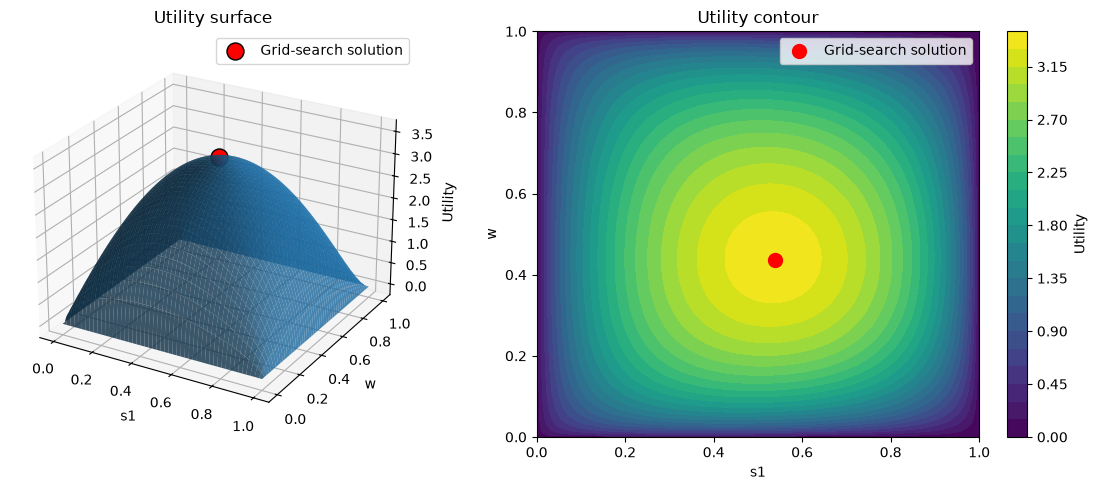

In [ ]:
# 2.1.2 - plot utility over the nested shares

fig = plt.figure(figsize=(12, 5))

# 3D surface plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')


ax1.plot_surface(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    alpha=0.8
)

# mark the grid-search solution
ax1.scatter(
    opt_grid.s1,
    opt_grid.w,
    opt_grid.u + 0.1,
    s=150,
    color='red',
    edgecolor='black',
    depthshade=False,
    label='Grid-search solution'
)

ax1.set_xlabel('s1')
ax1.set_ylabel('w')
ax1.set_zlabel('Utility')
ax1.set_title('Utility surface')

ax1.view_init(elev=25, azim=-60)
ax1.legend()

# contour plot
ax2 = fig.add_subplot(1, 2, 2)

contour = ax2.contourf(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    levels=30
)

# mark the solution
ax2.scatter(
    opt_grid.s1,
    opt_grid.w,
    s=100,
    color='red',
    label='Grid-search solution'
)

ax2.legend()

ax2.set_xlabel('s1')
ax2.set_ylabel('w')
ax2.set_title('Utility contour')

# add colorbar
fig.colorbar(contour, ax=ax2, label='Utility')

plt.tight_layout()
plt.show()

The figures show that utility reaches its maximum at an interior combination of s1 and w. The grid-search solution, approximately s1=0.538 and w=0.437, is located near the highest point of the utility surface and in the highest-utility region of the contour plot. This confirms the result obtained in Question 2.1.1.

2.1.3

In [ ]:
# grid sizes to compare
N_values = [50, 100, 500, 1000]

# solve the model for each grid size
for N in N_values:

    opt = model.solve_grid(N=N)

    # number of utility evaluations
    evaluations = N**2

    print("N =", N)
    print("s1 =", opt.s1)
    print("w =", opt.w)
    print("utility =", opt.u)
    print("utility evaluations =", evaluations)
    print()

N = 50
s1 = 0.5306122448979591
w = 0.44897959183673464
utility = 3.400747706799258
utility evaluations = 2500

N = 100
s1 = 0.5353535353535354
w = 0.4444444444444445
utility = 3.401482161126225
utility evaluations = 10000

N = 500
s1 = 0.5350701402805611
w = 0.438877755511022
utility = 3.40167436585882
utility evaluations = 250000

N = 1000
s1 = 0.5355355355355356
w = 0.4394394394394394
utility = 3.4016797975402664
utility evaluations = 1000000



Increasing the grid size makes the grid-search solution more precise, as a finer grid provides more possible combinations of s1 and w and therefore allows the solution to get closer to the true optimum. As N increases, the optimal values of s1 and w become increasingly stable around approximately s1=0.535 and w=0.439, while utility converges towards approximately 3.402. In particular, utility changes very little when increasing N from 500 to 1000, suggesting that the solution is converging. However, this increase in precision comes at a substantial computational cost, since the number of utility evaluations increases with N**2. Increasing N from 500 to 1000 therefore increases the number of evaluations from 250,000 to 1,000,000, despite only a very small improvement in utility. This illustrates the trade-off between precision and computational cost in a two-dimensional grid search.

2.1.4

In [ ]:
# 2.1.4 - compare the two calibrations

# complements calibration
model_comp = modelproject_2_1_2_2.ConsumerClass()

# substitutes calibration
model_sub = modelproject_2_1_2_2.ConsumerClass(
    par={'sigma_B': 3.0}
)

# solve both calibrations using the same grid size

opt_comp = model_comp.solve_grid(N=200)
opt_sub = model_sub.solve_grid(N=200)

# report optimal choices for both calibrations

print("Complements calibration:")
print("s1 =", opt_comp.s1)
print("w  =", opt_comp.w)

print("\nSubstitutes calibration:")
print("s1 =", opt_sub.s1)
print("w  =", opt_sub.w)

Complements calibration:
s1 = 0.5376884422110553
w  = 0.4371859296482412

Substitutes calibration:
s1 = 0.5376884422110553
w  = 0.6934673366834171


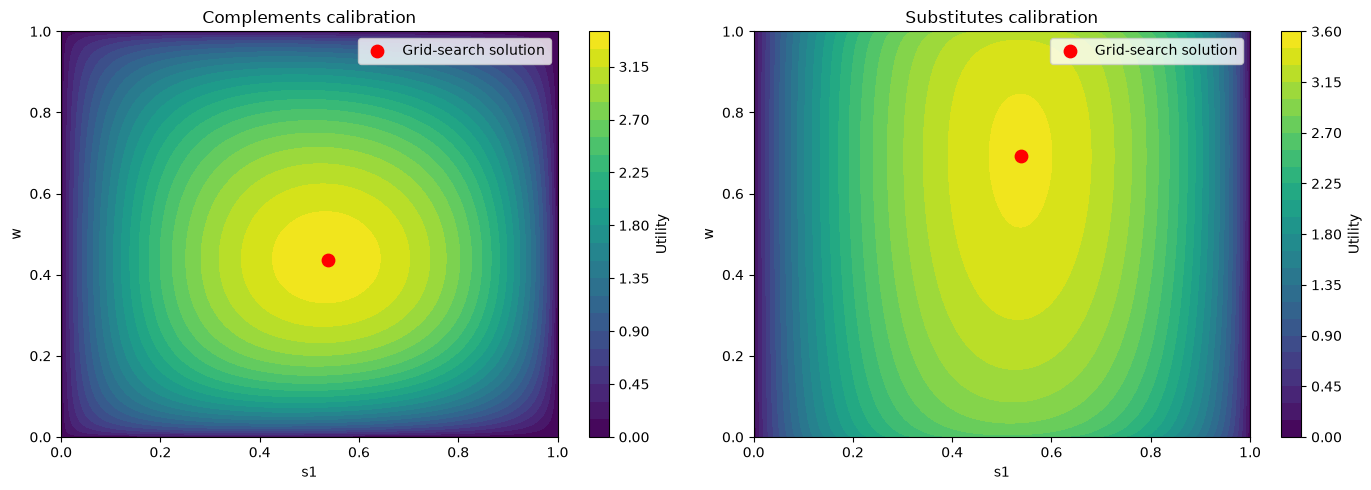

In [ ]:
# 2.1.4 - plot the two calibrations side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complements calibration
contour1 = axes[0].contourf(
    opt_comp.s1_grid,
    opt_comp.w_grid,
    opt_comp.u_grid,
    levels=30
)

axes[0].scatter(
    opt_comp.s1,
    opt_comp.w,
    color='red',
    s=80,
    label='Grid-search solution'
)

axes[0].set_xlabel('s1')
axes[0].set_ylabel('w')
axes[0].set_title('Complements calibration')
axes[0].legend()

fig.colorbar(contour1, ax=axes[0], label='Utility')


# Substitutes calibration
contour2 = axes[1].contourf(
    opt_sub.s1_grid,
    opt_sub.w_grid,
    opt_sub.u_grid,
    levels=30
)

axes[1].scatter(
    opt_sub.s1,
    opt_sub.w,
    color='red',
    s=80,
    label='Grid-search solution'
)

axes[1].set_xlabel('s1')
axes[1].set_ylabel('w')
axes[1].set_title('Substitutes calibration')
axes[1].legend()

fig.colorbar(contour2, ax=axes[1], label='Utility')

plt.tight_layout()
plt.show()

The complements calibration has a relatively well-defined optimum, as utility decreases when moving away from the optimum in both the s1 and w directions. In contrast, the substitutes calibration has more vertically elongated contours. This indicates that the utility surface is relatively flat in the w-direction, while it is steeper in the s1 direction. Consequently, changes in w around the optimum have a relatively small effect on utility. We would therefore expect the substitutes calibration to be harder for an optimizer, since the flatter objective function makes the precise optimal value of w more difficult to identify.

## Question 2.2 L-BFGS-B

2.2.1

In [ ]:
# solve the model using L-BFGS-B
opt_lbfgs = model_comp.solve()

In [ ]:
# report L-BFGS-B solution
print("L-BFGS-B solution:")
print("s1 =", opt_lbfgs.s1)
print("w =", opt_lbfgs.w)
print("utility =", opt_lbfgs.u)
print("function evaluations =", opt_lbfgs.nfev)

L-BFGS-B solution:
s1 = 0.5356233806953101
w = 0.43947902810370126
utility = 3.401679875985606
function evaluations = 18


In [ ]:
import time 

# running time for L-BFGS-B

start = time.perf_counter()

opt_lbfgs = model_comp.solve()

end = time.perf_counter()

time_lbfgs = end - start

print("L-BFGS-B running time =", time_lbfgs)

L-BFGS-B running time = 0.0011616246774792671


In [ ]:
# running time for grid search with N = 1000

start = time.perf_counter()

opt_grid_1000 = model_comp.solve_grid(N=1000)

end = time.perf_counter()

time_grid = end - start

print("Grid search running time =", time_grid)

Grid search running time = 0.0811060843989253


In [ ]:
# comparing the results 

print("Grid search (N=1000):")
print("s1 =", opt_grid_1000.s1)
print("w =", opt_grid_1000.w)
print("utility =", opt_grid_1000.u)
print("function evaluations =", 1000**2)
print("running time =", time_grid)

print("\nL-BFGS-B:")
print("s1 =", opt_lbfgs.s1)
print("w =", opt_lbfgs.w)
print("utility =", opt_lbfgs.u)
print("function evaluations =", opt_lbfgs.nfev)
print("running time =", time_lbfgs)

Grid search (N=1000):
s1 = 0.5355355355355356
w = 0.4394394394394394
utility = 3.4016797975402664
function evaluations = 1000000
running time = 0.0811060843989253

L-BFGS-B:
s1 = 0.5356233806953101
w = 0.43947902810370126
utility = 3.401679875985606
function evaluations = 18
running time = 0.0011616246774792671


The two methods give almost identical solutions. The grid search with N=1000 gives s1​≈0.53554 and w≈0.43944, while L-BFGS-B gives s1≈0.53562 and w≈0.43948. The corresponding utility levels are also almost identical, approximately 3.40168, showing that the two methods agree on the optimum.

However, L-BFGS-B is considerably more efficient. The grid search evaluates utility at 1,000,000 points and takes approximately 0.086 seconds, whereas L-BFGS-B requires only 18 function evaluations and takes approximately 0.0022 seconds. Thus, L-BFGS-B reaches essentially the same solution with far fewer function evaluations and substantially lower running time. This illustrates the advantage of using an optimization algorithm for a smooth problem rather than evaluating every point on a fine grid.

2.2.2

In [ ]:
# inspect the convergence path
# each row contains [s1, w] for one step taken by L-BFGS-B

print(opt_lbfgs.path)

[[0.5        0.5       ]
 [0.51661738 0.48338262]
 [0.5360763  0.43575106]
 [0.53560667 0.43965199]
 [0.53562338 0.43947903]]


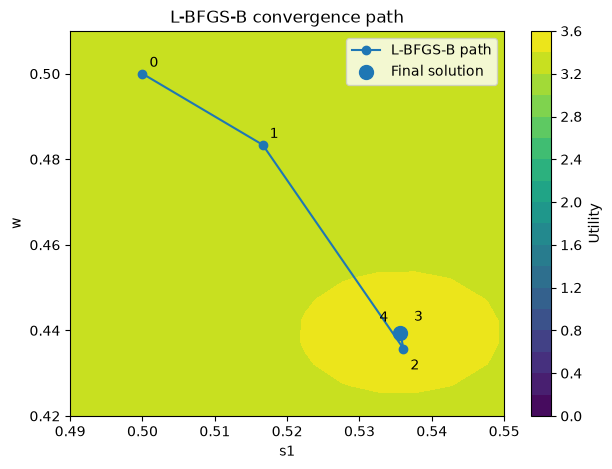

In [ ]:
# get the convergence path
path = opt_lbfgs.path

# create the contour plot
fig, ax = plt.subplots(figsize=(7,5))

contour = ax.contourf(
    opt_grid.s1_grid,
    opt_grid.w_grid,
    opt_grid.u_grid,
    levels=20
)

# plot the convergence path
ax.plot(
    path[:,0],
    path[:,1],
    marker='o',
    label='L-BFGS-B path'
)

# label each iteration
offsets = [(5,5), (5,5), (5,-15), (10,8), (-15,8)]

for k, (s1, w) in enumerate(path):
    ax.annotate(
        str(k),
        (s1, w),
        xytext=offsets[k],
        textcoords='offset points'
    )

# mark the final solution
ax.scatter(
    opt_lbfgs.s1,
    opt_lbfgs.w,
    s=100,
    label='Final solution'
)

# zoom in around the convergence path
ax.set_xlim(0.49, 0.55)
ax.set_ylim(0.42, 0.51)

# labels and title
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_title('L-BFGS-B convergence path')
ax.legend()

# add colorbar
fig.colorbar(contour, ax=ax, label='Utility')

plt.show()

In [ ]:
# convergence path
path = opt_lbfgs.path

# final solution found by L-BFGS-B
final_point = np.array([opt_lbfgs.s1, opt_lbfgs.w])

# calculate the distance from each point in the path
# to the final solution
distances = np.linalg.norm(path - final_point, axis=1)

# print the distance for each iteration
for i, distance in enumerate(distances):
    print(f"Iteration {i}: distance = {distance}")

Iteration 0: distance = 0.07022687015263869
Iteration 1: distance = 0.04784092033177335
Iteration 2: distance = 0.0037553834789245447
Iteration 3: distance = 0.00017376956291567552
Iteration 4: distance = 0.0


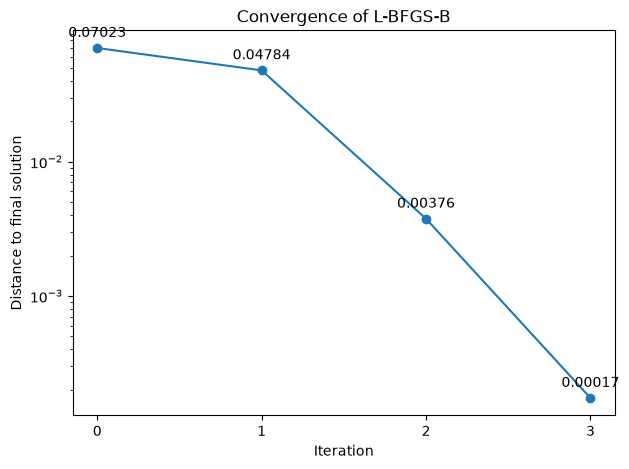

In [ ]:
# the convergence plot 

# exclude the final point because its distance is zero
iterations = np.arange(len(distances) - 1)
distances_plot = distances[:-1]

# plot distance to the final solution
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    iterations,
    distances_plot,
    marker='o'
)

# use a logarithmic scale on the y-axis
ax.set_yscale('log')

# labels and title
ax.set_xlabel('Iteration')
ax.set_ylabel('Distance to final solution')
ax.set_title('Convergence of L-BFGS-B')

# show each iteration number on the x-axis
ax.set_xticks(iterations)

# add distance labels to each point
for i, distance in zip(iterations, distances_plot):
    ax.annotate(
        f'{distance:.5f}',
        (i, distance),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

plt.show()

Conclusion:
The convergence path shows that L-BFGS-B moves quickly towards the optimal solution. The distance-to-final-solution plot gives a clearer picture of how fast it converges. The distance decreases from around 0.070 at the starting point to 0.048 after the first iteration, before falling much faster to 0.0038 and then 0.00017. On the log scale, we can therefore see that the distance decreases by several orders of magnitude in only a few iterations. Progress is relatively slow in the first iteration, while the largest improvements occur in the following iterations. Close to the optimum, only very small adjustments are needed. Together with the results from Question 2.2.1, this shows that L-BFGS-B is very efficient compared to the grid search, as it reaches almost the same solution using only 18 function evaluations compared to 1,000,000 with the grid search.

2.2.3 

In [ ]:
# starting points for L-BFGS-B
# includes the midpoint, all four corners, and one additional point

starting_points = [
    np.array([0.5, 0.5]),   # midpoint
    np.array([0.0, 0.0]),   # bottom-left corner
    np.array([0.0, 1.0]),   # top-left corner
    np.array([1.0, 0.0]),   # bottom-right corner
    np.array([1.0, 1.0]),   # top-right corner
    np.array([0.25, 0.75])  # additional starting point
]
# test different starting points for the complements calibration

for s0 in starting_points:

    # solve from this starting point
    opt = model_comp.solve(s0=s0)

    # print the most important results in one line
    print(
        f"start={s0}, "
        f"solution=({opt.s1:.4f}, {opt.w:.4f}), "
        f"utility={opt.u:.6f}, "
        f"iterations={opt.res.nit}, "
        f"success={opt.res.success}"
    )

start=[0.5 0.5], solution=(0.5356, 0.4395), utility=3.401680, iterations=4, success=True
start=[0. 0.], solution=(0.5356, 0.4395), utility=3.401680, iterations=7, success=True
start=[0. 1.], solution=(0.5356, 0.4395), utility=3.401680, iterations=9, success=True
start=[1. 0.], solution=(1.0000, 0.0000), utility=0.000000, iterations=1, success=True
start=[1. 1.], solution=(1.0000, 1.0000), utility=0.000000, iterations=1, success=True
start=[0.25 0.75], solution=(0.5356, 0.4395), utility=3.401680, iterations=6, success=True


In [ ]:
# test different starting points for the substitutes calibration

for s0 in starting_points:

    # solve from this starting point
    opt = model_sub.solve(s0=s0)

    # print the most important results in one line
    print(
        f"start={s0}, "
        f"solution=({opt.s1:.4f}, {opt.w:.4f}), "
        f"utility={opt.u:.6f}, "
        f"iterations={opt.res.nit}, "
        f"success={opt.res.success}"
    )

start=[0.5 0.5], solution=(0.5382, 0.6923), utility=3.485105, iterations=6, success=True
start=[0. 0.], solution=(0.5382, 0.6923), utility=3.485105, iterations=18, success=True
start=[0. 1.], solution=(0.5382, 0.6923), utility=3.485105, iterations=17, success=True
start=[1. 0.], solution=(0.5382, 0.6923), utility=3.485105, iterations=18, success=True
start=[1. 1.], solution=(0.5382, 0.6923), utility=3.485105, iterations=16, success=True
start=[0.25 0.75], solution=(0.5382, 0.6923), utility=3.485105, iterations=8, success=True


In [ ]:
# inspect the budget shares at the two problematic corners

for s0 in [np.array([1.0, 0.0]), np.array([1.0, 1.0])]:

    # calculate the implied budget shares
    s1, s2, s3 = model_comp.shares(s0[0], s0[1])

    print("Starting point:", s0)
    print("Budget shares:", s1, s2, s3)
    print()

Starting point: [1. 0.]
Budget shares: 1.0 0.0 0.0

Starting point: [1. 1.]
Budget shares: 1.0 0.0 0.0



Conclusion:
The results show that the final solution is generally not very sensitive to the starting point. For the substitutes calibration, all six starting points converge to approximately the same optimum, s1=0.5382 and w=0.6923. For the complements calibration, most starting points also converge to the same optimum, around s1=0.5356 and w=0.4395. The number of iterations does, however, change with the starting point. Some starting values are closer to the optimum and therefore require fewer iterations, while others take longer to converge.

One special case occurs in the complements calibration at the corner where all income is spent on good 1. In the nested-share representation, both (s1,w)=(1,0) and (1,1) imply the same budget shares, (s1,s2,s3)=(1,0,0), because w is irrelevant when s1=1. From this corner, the solver stays at the boundary and returns utility close to zero, even though it reports success=True. This shows that success=True only means that the numerical stopping criteria were satisfied; it does not guarantee that the solver has found the economically relevant optimum.

2.2.4

In [ ]:
# tolerance values to test

ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]

gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]

In [ ]:
# create an empty list to store all results
results = []

# define the two calibrations
models = {
    'Complements': model_comp,
    'Substitutes': model_sub
}

# run the tests for both calibrations
for calibration, model in models.items():

    # test the different ftol values
    for ftol in ftol_values:

        opt = model.solve(
            s0=np.array([0.5, 0.5]),
            options={'ftol': ftol}
        )

        # save the results
        results.append({
            'Calibration': calibration,
            'Setting': 'ftol',
            'Tolerance': ftol,
            's1': opt.s1,
            'w': opt.w,
            'Utility': opt.u,
            'Function evaluations': opt.nfev
        })

    # test the different gtol values
    for gtol in gtol_values:

        opt = model.solve(
            s0=np.array([0.5, 0.5]),
            options={'gtol': gtol}
        )

        # save the results
        results.append({
            'Calibration': calibration,
            'Setting': 'gtol',
            'Tolerance': gtol,
            's1': opt.s1,
            'w': opt.w,
            'Utility': opt.u,
            'Function evaluations': opt.nfev
        })

In [ ]:
# convert the stored results into a table
tolerance_table = pd.DataFrame(results)

# display the table
tolerance_table

,Calibration,Setting,Tolerance,s1,w,Utility,Function evaluations
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


Conclusion: 2.2.4 + 2.2.5

For both calibrations, tighter tolerances initially improve the solution, but after a certain point the solution and utility barely change. At the same time, tighter tolerances generally require more function evaluations. This shows a trade-off between precision and computational cost: after a certain point, more computation gives almost no improvement in the solution or utility. For example, using ftol = 1e-8 gives essentially the same result as ftol = 1e-12 and 1e-16. Similarly, gtol = 1e-5 is already sufficient to obtain almost the same solution as the tighter values. I would therefore use ftol = 1e-8 and gtol = 1e-5, since they give an accurate solution without unnecessary function evaluations. 

A tighter tolerance is not always better because it can require more function evaluations without meaningfully improving the solution or utility. A tighter tolerance requires the optimizer to reach a higher level of precision before it stops. This increases the computational cost, even though the optimizer does not produce a noticeably better result.

# Question 3

In question 3 we study how a increase in train tickets affect the consumer. 

In [ ]:
# Train ticket prices from 0.5 to 3.0
p3_values = np.linspace(0.5, 3.0, 50)

# Empty lists for complements
s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []


# Empty lists for substitutes
s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

# Solve for complements
for p3 in p3_values:
    
    model_comp = ConsumerClass(par={'sigma_B': 0.4, 'p3': p3})
    opt_comp = model_comp.solve()

    # Save budget shares
    s1_comp.append(opt_comp.s1)
    s2_comp.append(opt_comp.s2)
    s3_comp.append(opt_comp.s3)

    # Calculate quantities
    x1, x2, x3 = model_comp.quantities(opt_comp.s1, opt_comp.w)

    # Save quantities
    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


# Solve for substitutes
for p3 in p3_values:
    
    model_sub = ConsumerClass(par={'sigma_B': 3.0, 'p3': p3})
    opt_sub = model_sub.solve()

    # Save budget shares
    s1_sub.append(opt_sub.s1)
    s2_sub.append(opt_sub.s2)
    s3_sub.append(opt_sub.s3)

    # Calculate quantities
    x1, x2, x3 = model_sub.quantities(opt_sub.s1, opt_sub.w)

    # Save quantities
    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)   

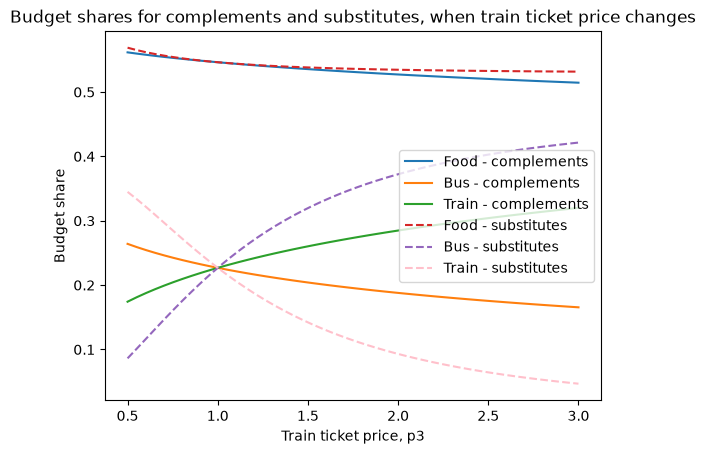

In [ ]:
# Plot budget shares

plt.figure()

plt.plot(p3_values, s1_comp, label='Food - complements')
plt.plot(p3_values, s2_comp, label='Bus - complements')
plt.plot(p3_values, s3_comp, label='Train - complements')

plt.plot(p3_values, s1_sub, '--', label='Food - substitutes')
plt.plot(p3_values, s2_sub, '--', label='Bus - substitutes')
plt.plot(p3_values, s3_sub, '--', color='pink', label='Train - substitutes')

plt.title('Budget shares for complements and substitutes, when train ticket price changes')
plt.xlabel('Train ticket price, p3')
plt.ylabel('Budget share')
plt.legend()


plt.show()

3.2 – Budget shares

The figure shows how the optimal budget shares change as the train ticket price increases. When bus and train are complements, a higher train ticket price increases the budget share spent on train, while the budget share spent on bus decreases. When bus and train are substitutes, the opposite occurs: the train budget share decreases and the bus budget share increases as the consumer shifts expenditure towards bus travel. The budget share spent on food changes relatively little in both calibrations.

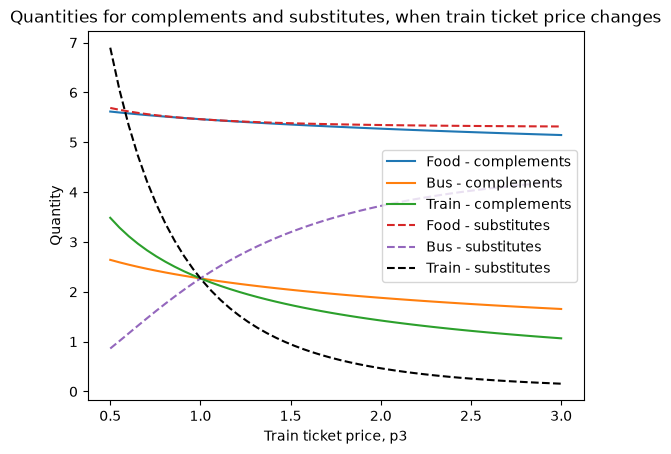

In [ ]:
# Plot quantities

plt.figure()

plt.plot(p3_values, x1_comp, label='Food - complements')
plt.plot(p3_values, x2_comp, label='Bus - complements')
plt.plot(p3_values, x3_comp, label='Train - complements')

plt.plot(p3_values, x1_sub, '--', label='Food - substitutes')
plt.plot(p3_values, x2_sub, '--', label='Bus - substitutes')
plt.plot(p3_values, x3_sub, '--', color='black', label='Train - substitutes')

plt.title('Quantities for complements and substitutes, when train ticket price changes')
plt.xlabel('Train ticket price, p3')
plt.ylabel('Quantity')
plt.legend()
plt.show()

3.3 – Bus trips

The effect on the number of bus trips differs clearly between the two calibrations. When bus and train are complements, the number of bus trips decreases as train tickets become more expensive. Since the two modes are consumed together, lower demand for train travel is accompanied by lower demand for bus travel. When bus and train are substitutes, the number of bus trips instead increases because the consumer substitutes away from the more expensive train and towards bus travel. The number of train trips decreases in both calibrations.


In [ ]:
# Changes in demand when p3 increases from 0.5 to 3.0

print('Complements:')
print(f'Change in food demand: {x1_comp[-1] - x1_comp[0]:.3f}')
print(f'Change in bus demand: {x2_comp[-1] - x2_comp[0]:.3f}')

print('\nSubstitutes:')
print(f'Change in food demand: {x1_sub[-1] - x1_sub[0]:.3f}')
print(f'Change in bus demand: {x2_sub[-1] - x2_sub[0]:.3f}')

Complements:
Change in food demand: -0.471
Change in bus demand: -0.986

Substitutes:
Change in food demand: -0.372
Change in bus demand: 3.353


3.4 – Food demand

When the train ticket price increases from 0.5 to 3.0, food demand decreases by approximately 0.471 in the complements calibration and by 0.372 in the substitutes calibration. The effect on bus demand is larger: bus demand decreases by approximately 0.986 when bus and train are complements, while it increases by approximately 3.353 when they are substitutes. Thus, changes in the train ticket price have a relatively small effect on food demand compared with bus demand. This reflects that most of the adjustment to a change in the train ticket price takes place within the travel nest, especially when bus and train are substitutes.


# Question 4

# 4 Lump-sum taxes and product taxes

The government needs revenue and has two kinds of instrument: a **lump-sum tax** $T$, which lowers income to $I-T$, and **product taxes** $\tau_j\geq 0$, which raise the price of good $j$ from $p_j$ to $(1+\tau_j)p_j$. Total revenue is

$$R = T + \sum_{j=1}^{3}\tau_j p_j x_j^{\star},$$

where $x_j^{\star}$ is what the consumer buys *given the taxes*. The revenue leaves the model.

All the government does is translate the taxes into the prices and the income the consumer faces, so everything from sections 1-3 keeps working unchanged. Two taxes that raise the same revenue are compared by the utility the consumer is left with: higher is better.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from Consumer import ConsumerClass
from Government import GovernmentClass, TAX_DIRECTIONS

In [2]:
# one government per calibration
gov_comp = GovernmentClass(ConsumerClass())
gov_sub  = GovernmentClass(ConsumerClass(par={'sigma_B':3.0}))

govs = {'Complements':gov_comp,'Substitutes':gov_sub}

print(gov_comp)

GovernmentClass
  pre-tax prices = [1.  1.  1.5], pre-tax income = 10.0000
  T = 0.0000, tau = [0. 0. 0.]
  consumer faces:
    ConsumerClass
      alpha = 0.6000, beta = 0.5000
      sigma_A = 0.8000, sigma_B = 0.4000
      p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
      I = 10.0000


## 4.1 Implementing `tax_revenue()`

`set_taxes()` writes the taxes into the consumer's prices and income, `tax_revenue()` then re-solves the consumer at those prices and evaluates eq. 5. Three cheap checks: with no taxes the revenue is zero and we are back at the solution from question 2; a pure lump-sum tax raises exactly $T$; and a tax on food only raises exactly $\tau_1 p_1 x_1$.

In [3]:
for name,gov in govs.items():

    print(name)

    # a. no taxes at all
    base = gov.tax_revenue()
    print(f'  no taxes : R = {base.R:.4f}, u = {base.u:.4f}, shares = {np.round(base.s,4)}')

    # b. a pure lump-sum tax
    lump = gov.tax_revenue(T=1.0)
    print(f'  T = 1.0  : R = {lump.R:.4f}, u = {lump.u:.4f}')

    # c. a product tax on food only
    prod = gov.tax_revenue(tau=np.array([0.5,0.0,0.0]))
    print(f'  tau1= 0.5: R = {prod.R:.4f}, u = {prod.u:.4f}')

    # d. the checks
    assert np.isclose(base.R,0.0), 'no taxes must give no revenue'
    assert np.isclose(lump.R,1.0), 'a lump-sum tax must raise exactly T'
    assert np.isclose(prod.R,0.5*gov.par.p0[0]*prod.x[0]), 'eq. 5 does not hold'
    assert np.isclose(np.sum(prod.s),1.0), 'the budget shares must still sum to one'

print('')
print('All tests passed')

Complements
  no taxes : R = 0.0000, u = 3.4017, shares = [0.5356 0.2041 0.2603]
  T = 1.0  : R = 1.0000, u = 3.0615
  tau1= 0.5: R = 1.8524, u = 2.7265
Substitutes
  no taxes : R = 0.0000, u = 3.4851, shares = [0.5382 0.3197 0.1421]
  T = 1.0  : R = 1.0000, u = 3.1366
  tau1= 0.5: R = 1.8610, u = 2.7904

All tests passed


The utility with no taxes is 3.4017 in the complements calibration and 3.4851 in the substitutes calibration, exactly as in question 2, and the budget shares still sum to one. The taxes therefore only change the prices and the income, not the model.

## 4.2 Revenue as a function of the tax rate

We consider five product taxes -- on food only, on the bus only, on the train only, the same rate on bus and train, and the same rate on all three goods -- and plot the revenue for rates from 0 to 3, one panel per calibration.

In [4]:
# a grid over the tax rate
tau_rates = np.linspace(0.0,3.0,100)

# compute the revenue (and the utility, we use it in 4.4) for every tax
curves = {}

for name,gov in govs.items():

    curves[name] = {}

    for label in TAX_DIRECTIONS:
        R,u = gov.revenue_curve(tau_rates,label)
        curves[name][label] = (R,u)

print('done')

done


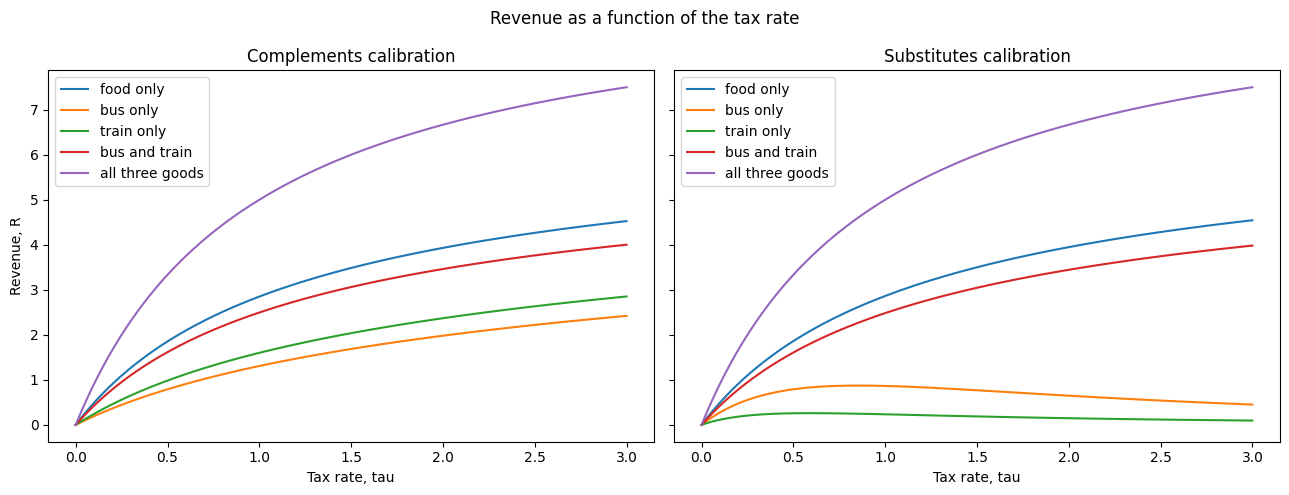

In [5]:
fig,axes = plt.subplots(1,2,figsize=(13,5),sharey=True)

for ax,(name,gov) in zip(axes,govs.items()):

    for label in TAX_DIRECTIONS:
        R,u = curves[name][label]
        ax.plot(tau_rates,R,label=label)

    ax.set_xlabel('Tax rate, tau')
    ax.set_title(name+' calibration')
    ax.legend()

axes[0].set_ylabel('Revenue, R')

fig.suptitle('Revenue as a function of the tax rate')
plt.tight_layout()
plt.show()

## 4.3 Which curves have a top?

We find the top of each curve with a grid search over the tax rate, exactly as in section 2.1. The figure above shows that only the taxes in the substitutes calibration turn around inside $[0,3]$, but we also run the grid all the way out to $\tau=20$ to make sure that the other curves really do keep rising.

In [6]:
rows = []

for name,gov in govs.items():
    for label in TAX_DIRECTIONS:

        # a. the top on the plotted range
        near = gov.max_revenue(label,tau_max=3.0,N=3001)

        # b. a much wider grid, to check that the rising curves keep rising
        far = gov.max_revenue(label,tau_max=20.0,N=1001)

        rows.append({
            'Calibration':name,
            'Tax':label,
            'Has a top':near.interior,
            'tau*':near.tau_star if near.interior else np.nan,
            'R at the top':near.R_max if near.interior else np.nan,
            'R at tau=3':near.R_grid[-1],
            'R at tau=20':far.R_grid[-1]})

laffer_table = pd.DataFrame(rows)
laffer_table

,Calibration,Tax,Has a top,tau*,R at the top,R at tau=3,R at tau=20
0,Complements,food only,False,NaN,NaN,4.526108,6.471761
1,Complements,bus only,False,NaN,NaN,2.420563,4.450666
2,Complements,train only,False,NaN,NaN,2.850957,4.884355
3,Complements,bus and train,False,NaN,NaN,4.001854,5.852166
4,Complements,all three goods,False,NaN,NaN,7.500000,9.523810
5,Substitutes,food only,False,NaN,NaN,4.544876,6.493434
6,Substitutes,bus only,True,0.856,0.872144,0.451121,0.023739
7,Substitutes,train only,True,0.593,0.259040,0.095320,0.004513
8,Substitutes,bus and train,False,NaN,NaN,3.982312,5.828542
9,Substitutes,all three goods,False,NaN,NaN,7.500000,9.523810


In [7]:
# the question asked in the problem set: the most a tax on train tickets alone
# can ever raise in the substitutes calibration

top_train = gov_sub.max_revenue('train only',tau_max=3.0,N=3001)

print(f'revenue-maximizing rate : tau = {top_train.tau_star:.4f}')
print(f'largest possible revenue: R   = {top_train.R_max:.4f}')
print(f'                        = {100*top_train.R_max/gov_sub.par.I0:.2f} percent of income')

revenue-maximizing rate : tau = 0.5930
largest possible revenue: R   = 0.2590
                        = 2.59 percent of income


Only two curves have a top, and both of them are in the **substitutes** calibration: the tax on the bus alone, which peaks at $\tau\approx0.86$ with a revenue of $0.87$, and the tax on the train alone, which peaks at $\tau\approx0.59$ with a revenue of only $0.26$. When bus and train are close substitutes, the consumer answers a tax on one of them by moving to the other, so the tax base disappears faster than the rate rises and the curve bends back down. A tax on train tickets alone can therefore **never raise more than about 0.26**, i.e. 2.6 percent of income, no matter how high the rate is set.

All the other curves keep rising. A tax on food, or on bus and train together, cannot be escaped by moving inside the nest: the only way out is to substitute between food and travel, and $\sigma_A = 0.80 < 1$ makes that hard, so the share spent on the taxed good actually *rises* with the rate. The tax on all three goods is the extreme case: it leaves every relative price unchanged, so the shares do not move at all and the revenue is exactly $R = \frac{\tau}{1+\tau}I$, which rises towards the whole income. Note also that the two tops only exist in the substitutes calibration: with $\sigma_B = 0.40$ the same taxes are on the rising part of the curve everywhere we look.

## 4.4 Utility against the revenue raised

For each instrument we now plot the utility the consumer is left with against the revenue it raises. The lump-sum tax is added by letting $T$ run from 0 upwards.

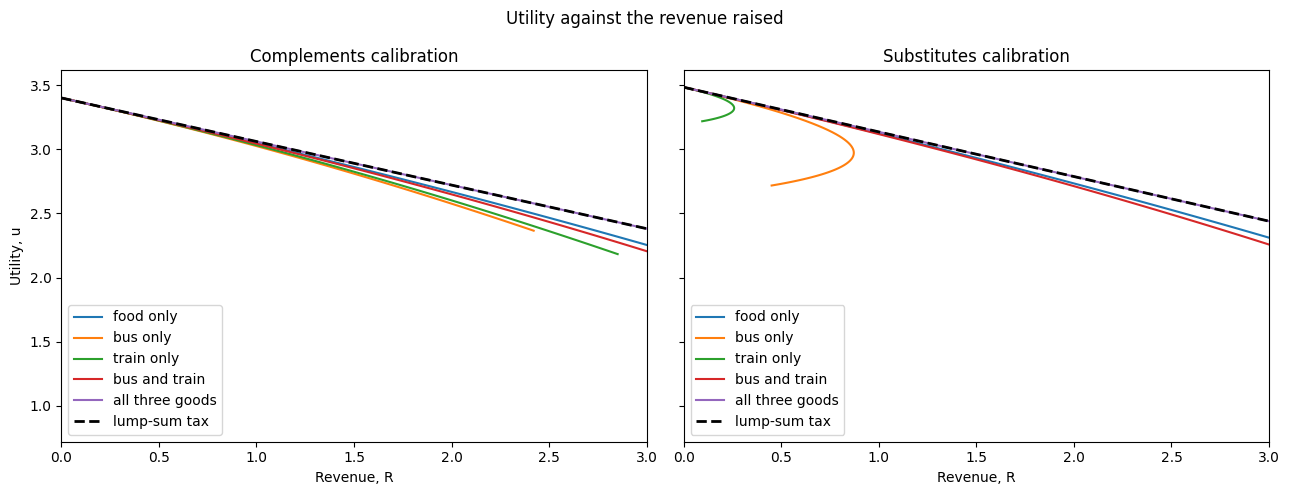

In [8]:
# the lump-sum tax
T_values = np.linspace(0.0,5.0,100)

lump_curves = {}

for name,gov in govs.items():
    lump_curves[name] = gov.lump_sum_curve(T_values)

# the figure
fig,axes = plt.subplots(1,2,figsize=(13,5),sharey=True)

for ax,(name,gov) in zip(axes,govs.items()):

    for label in TAX_DIRECTIONS:
        R,u = curves[name][label]
        ax.plot(R,u,label=label)

    R,u = lump_curves[name]
    ax.plot(R,u,'k--',lw=2,label='lump-sum tax')

    ax.set_xlim(0,3)
    ax.set_xlabel('Revenue, R')
    ax.set_title(name+' calibration')
    ax.legend()

axes[0].set_ylabel('Utility, u')

fig.suptitle('Utility against the revenue raised')
plt.tight_layout()
plt.show()

The lump-sum tax lies weakly above every product tax in both calibrations, so it is the cheapest way to raise any given revenue. That is the standard result: a lump-sum tax lowers income without touching any relative price, so it has no substitution effect and no excess burden.

The tax on **all three goods** lies exactly on top of the lump-sum line. That is not a numerical accident. A uniform tax leaves all relative prices unchanged, so the budget shares do not move, and revenue is $R = \frac{\tau}{1+\tau}I$ while the consumer's real income is $\frac{I}{1+\tau} = I-R$. A uniform product tax on everything *is* a lump-sum tax in disguise.

The ranking of the remaining instruments does depend on the calibration. In the complements calibration the four narrow taxes are all close to the lump-sum line, because the consumer cannot escape any of them. In the substitutes calibration the tax on the train is clearly the worst instrument, and its curve even bends backwards: past $\tau\approx0.59$ the government raises *less* revenue while the consumer is worse off, so every point on that part of the curve is dominated.

## 4.5 Raising R = 0.20 with each instrument

The government needs $R = 0.20$, i.e. 2 percent of income. For each instrument we find the rate that raises exactly that with `optimize.root_scalar(...,method='brentq')` on revenue minus the target.

Because utility is homogeneous of degree one in income here, we can also translate the utility loss into money: $\lambda = u_0/I$ is the marginal utility of income with no taxes, so $(u_0-u)/\lambda$ is the income the consumer would have to be given to be as well off as before. Subtracting the 0.20 the government actually gets leaves the **excess burden**.

In [9]:
tables = {}

for name,gov in govs.items():

    # a. the no-tax benchmark
    u0 = gov.tax_revenue().u
    lam = u0/gov.par.I0 # marginal utility of income

    rows = []

    # b. the lump-sum tax
    out = gov.find_lump_sum(0.20)
    rows.append({'Instrument':'lump-sum','Rate':out.rate,'R':out.R,'Utility':out.u})

    # c. the five product taxes
    for label in TAX_DIRECTIONS:

        # the bracket must stop at the top of the curve, if there is one,
        # so that brentq picks the low rate on the rising part
        top = gov.max_revenue(label,tau_max=5.0,N=501)
        upper = top.tau_star if top.interior else 5.0

        out = gov.find_rate(0.20,label,bracket=(0.0,upper))
        rows.append({'Instrument':label,'Rate':out.rate,'R':out.R,'Utility':out.u})

    # d. the money cost
    table = pd.DataFrame(rows)
    table['Income cost'] = (u0-table['Utility'])/lam
    table['Excess burden'] = table['Income cost']-0.20
    table['Pct of revenue'] = 100*table['Excess burden']/0.20

    tables[name] = table.sort_values('Utility',ascending=False).reset_index(drop=True)

print('Complements calibration')
tables['Complements']

Complements calibration


,Instrument,Rate,R,Utility,Income cost,Excess burden,Pct of revenue
0,lump-sum,0.200000,0.2,3.333646,0.200000,-2.498002e-15,-1.249001e-12
1,all three goods,0.020408,0.2,3.333646,0.200000,7.860379e-13,3.930190e-10
2,food only,0.038647,0.2,3.333169,0.201403,1.402627e-03,7.013137e-01
3,bus and train,0.044787,0.2,3.333010,0.201870,1.870162e-03,9.350811e-01
4,train only,0.081011,0.2,3.332548,0.203229,3.229336e-03,1.614668e+00
5,bus only,0.104215,0.2,3.332260,0.204074,4.074332e-03,2.037166e+00


In [10]:
print('Substitutes calibration')
tables['Substitutes']

Substitutes calibration


,Instrument,Rate,R,Utility,Income cost,Excess burden,Pct of revenue
0,lump-sum,0.200000,0.2,3.415402,0.200000,-1.759703e-14,-8.798517e-12
1,all three goods,0.020408,0.2,3.415402,0.200000,5.978551e-13,2.989275e-10
2,food only,0.038454,0.2,3.414919,0.201388,1.387833e-03,6.939163e-01
3,bus and train,0.045049,0.2,3.414744,0.201890,1.890081e-03,9.450403e-01
4,bus only,0.069532,0.2,3.412375,0.208688,8.688105e-03,4.344053e+00
5,train only,0.236217,0.2,3.395521,0.257046,5.704638e-02,2.852319e+01


In [11]:
# the train tax in the substitutes calibration: R = 0.20 can be raised at two rates

low  = gov_sub.find_rate(0.20,'train only',bracket=(0.0,top_train.tau_star))
high = gov_sub.find_rate(0.20,'train only',bracket=(top_train.tau_star,3.0))

print(f'low rate : tau = {low.rate:.4f}, R = {low.R:.4f}, u = {low.u:.4f}')
print(f'high rate: tau = {high.rate:.4f}, R = {high.R:.4f}, u = {high.u:.4f}')
print('')
print(f'R = 0.20 is {100*0.20/top_train.R_max:.1f} percent of the most this tax can ever raise')

low rate : tau = 0.2362, R = 0.2000, u = 3.3955
high rate: tau = 1.3572, R = 0.2000, u = 3.2571

R = 0.20 is 77.2 percent of the most this tax can ever raise


**Ranking.** In both calibrations the ranking is: lump-sum tax = tax on all three goods, then food, then bus and train together, and last one of the two narrow travel taxes. The excess burden is tiny for the first instruments -- below 1 percent of the revenue -- and the whole ranking is driven by how easily the consumer can get away from the taxed good.

The interesting case is the **tax on train tickets**. In the complements calibration it needs a rate of 8.1 percent and wastes 1.6 percent of the revenue, which is unremarkable. In the substitutes calibration the very same instrument needs a rate of 23.6 percent -- three times as high -- and the excess burden is 28.5 percent of the revenue: for every krone the government collects, the consumer loses 1.29. The reason is visible in question 4.3: with $\sigma_B = 3$ the consumer moves to the bus as soon as the train gets more expensive, so the tax base shrinks and the rate has to be pushed up a long way. Worse, $R=0.20$ is already 77 percent of the *most* this tax can ever raise (0.26), so the government is operating close to the top of its Laffer curve. The same 0.20 can in fact be raised at two different rates, 0.2362 and 1.3572; the high one raises the same revenue with much lower utility and would obviously never be chosen.

The general lesson is the one behind the Ramsey rule: a narrow tax on a good with a close substitute is the most expensive way to raise revenue, and how expensive it is depends entirely on the substitution elasticity, not on the tax rate itself.

# Question 5

# 5 Extension: a green tax on travel, with the revenue paid back

In section 4 the revenue leaves the model and the government has no reason to prefer one good over another. We extend the model in two directions.

1. **Travel pollutes.** Every unit of good $j$ emits $e_j$, so total emissions are $E = \sum_j e_j x_j$. Bus trips run on diesel and are dirty, $e_2 = 0.10$; train trips run on electricity and are much cleaner, $e_3 = 0.02$; food is left out of the transport externality, $e_1 = 0$. Social welfare is
$$W = u - \delta E,$$
with $\delta = 1$ the damage from one unit of emissions, measured in utility units.

2. **The revenue is rebated.** The government hands the revenue straight back as a lump-sum transfer, so the tax is revenue neutral and only the *relative prices* do any work. This makes the model a **fixed point**: income is $I + R$, but $R$ depends on what the consumer buys and therefore on income. We solve it with `optimize.root_scalar`.

The question we ask is the one a transport ministry actually asks: *what is the cheapest way to cut emissions, and does the answer depend on how easily people can switch between bus and train?*

In [12]:
from extension import GreenGovernmentClass

green_comp = GreenGovernmentClass(ConsumerClass())
green_sub  = GreenGovernmentClass(ConsumerClass(par={'sigma_B':3.0}))

greens = {'Complements':green_comp,'Substitutes':green_sub}

print('emission intensities e =',green_comp.par.e)
print('damage per unit delta =',green_comp.par.delta)

emission intensities e = [0.   0.1  0.02]
damage per unit delta = 1.0


### 5.1 Emissions with no taxes

In [13]:
for name,green in greens.items():

    eq = green.solve_with_rebate(np.zeros(3))

    print(name)
    print(f'  quantities = {np.round(eq.x,4)}')
    print(f'  emissions  = {eq.E:.4f}')
    print(f'  utility    = {eq.u:.4f}, welfare = {eq.W:.4f}')

Complements
  quantities = [5.3562 2.0408 1.7353]
  emissions  = 0.2388
  utility    = 3.4017, welfare = 3.1629
Substitutes
  quantities = [5.3823 3.1969 0.9472]
  emissions  = 0.3386
  utility    = 3.4851, welfare = 3.1465


The substitutes consumer pollutes considerably more to begin with (0.339 against 0.239). Nothing green is going on: the bus is simply the cheaper of the two ways of travelling, and a consumer who is happy to substitute buys mostly the cheap one -- which here happens to be the dirty one.

### 5.2 Two checks on the fixed point

First, with the revenue rebated a tax at the *same* rate on all three goods must do nothing at all: it leaves every relative price unchanged and the rebate gives the lost income straight back. Second, preferences are homothetic, so the budget shares do not depend on income and the fixed point can be solved by hand: $R = I_{net}\Phi$ with $\Phi = \sum_j \frac{\tau_j s_j}{1+\tau_j}$ and $I_{net} = I+R$, so $R = I\Phi/(1-\Phi)$. The root-finder should agree with that.

In [14]:
for name,green in greens.items():

    # a. neutrality of a uniform tax
    eq0 = green.solve_with_rebate(np.zeros(3))
    eq1 = green.solve_with_rebate(np.array([0.5,0.5,0.5]))

    print(name)
    print(f'  uniform tax : u = {eq1.u:.6f} vs {eq0.u:.6f}, E = {eq1.E:.6f} vs {eq0.E:.6f}')

    # b. root-finder against the closed form
    tau = np.array([0.0,0.3,0.05])
    eq = green.solve_with_rebate(tau)
    print(f'  rebate      : root-finder {eq.rebate:.8f}, closed form {green.rebate_closed_form(tau):.8f}')

    assert np.isclose(eq1.u,eq0.u) and np.isclose(eq1.E,eq0.E), 'a uniform tax should be neutral'
    assert np.isclose(eq.rebate,green.rebate_closed_form(tau)), 'the fixed point is wrong'

print('')
print('All tests passed')

Complements
  uniform tax : u = 3.401680 vs 3.401680, E = 0.238789 vs 0.238789
  rebate      : root-finder 0.67426124, closed form 0.67426124


Substitutes
  uniform tax : u = 3.485105 vs 3.485105, E = 0.338635 vs 0.338635


  rebate      : root-finder 0.79616903, closed form 0.79616903



All tests passed


Both checks pass. The neutrality result also tells us something about the *model*: with the revenue rebated, only two relative prices are free, so from here on we normalize $\tau_1 = 0$ and let the government choose the taxes on bus and train.

### 5.3 Emissions as a function of a tax on the bus

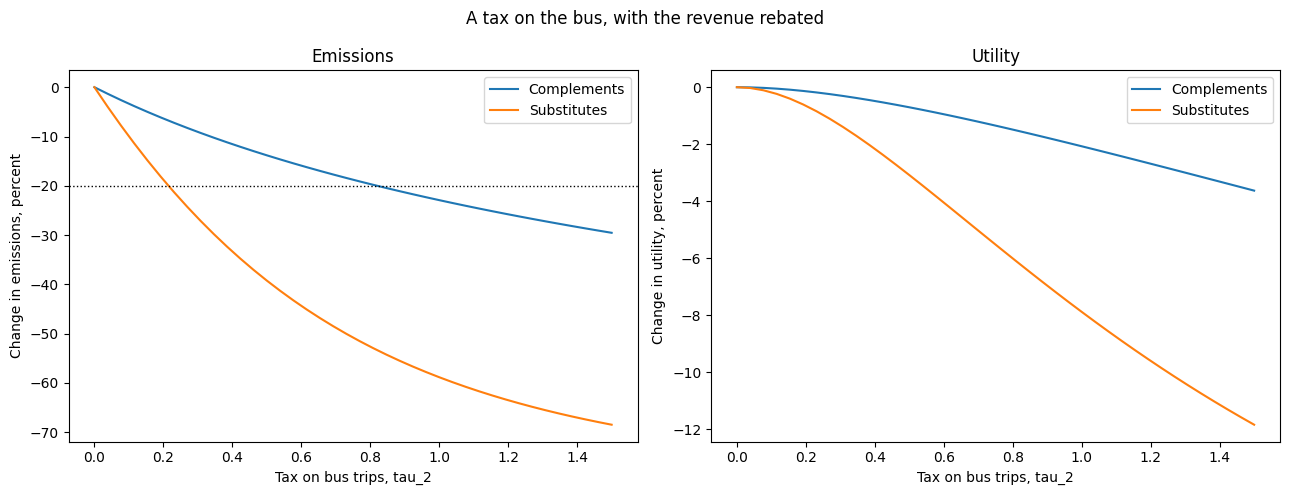

In [15]:
bus_rates = np.linspace(0.0,1.5,40)

fig,axes = plt.subplots(1,2,figsize=(13,5))

for name,green in greens.items():

    E = np.empty(bus_rates.size)
    u = np.empty(bus_rates.size)

    for i,rate in enumerate(bus_rates):
        eq = green.solve_with_rebate(np.array([0.0,rate,0.0]))
        E[i] = eq.E
        u[i] = eq.u

    # emissions relative to no tax
    axes[0].plot(bus_rates,100*(E/E[0]-1),label=name)
    axes[1].plot(bus_rates,100*(u/u[0]-1),label=name)

axes[0].axhline(-20,color='k',ls=':',lw=1)
axes[0].set_ylabel('Change in emissions, percent')
axes[1].set_ylabel('Change in utility, percent')

for ax in axes:
    ax.set_xlabel('Tax on bus trips, tau_2')
    ax.legend()

axes[0].set_title('Emissions')
axes[1].set_title('Utility')

fig.suptitle('A tax on the bus, with the revenue rebated')
plt.tight_layout()
plt.show()

The two calibrations react very differently to the same instrument. In the substitutes calibration a modest tax on the bus cuts emissions sharply, because the consumer moves to the train, which is five times cleaner. In the complements calibration the same tax barely moves emissions: the consumer wants bus and train together, so the only way to pollute less is to travel less, and that is expensive. The utility panel shows the mirror image: the tax that does the most for emissions is also the one that costs the least utility.

### 5.4 The cheapest way to cut emissions by 20 percent

We compare three instruments, each scaled by a root-finder until emissions are exactly 20 percent below their no-tax level:

- a tax on the **bus only**,
- a **uniform travel tax**, the same rate on bus and train,
- an **emission-proportional** tax, $\tau_j \propto e_j/p_j$, normalized so that the bus rate is the free one.

The cost is again measured as the income the consumer would need to be given to be as well off as with no tax at all.

In [16]:
rows = []

for name,green in greens.items():

    # a. the no-tax benchmark
    eq0 = green.solve_with_rebate(np.zeros(3))
    lam = eq0.u/green.par.I0

    # b. the three directions
    intensity = green.par.e/green.par.p0
    directions = {
        'bus only'             : np.array([0.0,1.0,0.0]),
        'uniform travel tax'   : np.array([0.0,1.0,1.0]),
        'emission-proportional': intensity/np.max(intensity)}

    for label,direction in directions.items():

        out = green.find_rate_for_emissions(0.20,direction,bracket=(0.0,20.0))

        rows.append({
            'Calibration':name,
            'Instrument':label,
            'Rate':out.rate,
            'tau_2':out.tau[1],
            'tau_3':out.tau[2],
            'Emissions':out.E,
            'Utility':out.u,
            'Income cost':(eq0.u-out.u)/lam})

cut_table = pd.DataFrame(rows)
cut_table

,Calibration,Instrument,Rate,tau_2,tau_3,Emissions,Utility,Income cost
0,Complements,bus only,0.820232,0.820232,0.000000,0.191031,3.349154,0.154411
1,Complements,uniform travel tax,0.614149,0.614149,0.614149,0.191031,3.325845,0.222933
2,Complements,emission-proportional,0.781974,0.781974,0.104263,0.191031,3.350786,0.149614
3,Substitutes,bus only,0.214931,0.214931,0.000000,0.270908,3.459263,0.074149
4,Substitutes,uniform travel tax,0.611046,0.611046,0.611046,0.270908,3.408117,0.220904
5,Substitutes,emission-proportional,0.239375,0.239375,0.031917,0.270908,3.459547,0.073335


Two things stand out.

**The same target is twice as cheap when the two modes are substitutes.** Cutting emissions by 20 percent costs about 0.15 units of income in the complements calibration and only 0.07 in the substitutes calibration. The reason is that the substitutes consumer can keep travelling just as much and simply switch from bus to train, while the complements consumer has to give up travel altogether. The elasticity of substitution *inside* the nest is what decides how expensive climate policy is, and it does not appear anywhere in the emission accounting.

**A blunt instrument is much worse than a targeted one.** The uniform travel tax has to raise the price of the clean mode as much as the dirty one, so it can only cut emissions by cutting travel: it costs 0.22 units of income in both calibrations, three times the targeted instrument in the substitutes calibration. The emission-proportional tax is the cheapest of the three in both calibrations, but only barely better than taxing the bus alone -- which makes sense, since the bus is responsible for most of the emissions to begin with.

### 5.5 The welfare-maximizing green tax

Finally we let the government choose $(\tau_2,\tau_3)$ freely to maximize $W = u-\delta E$, using L-BFGS-B on the box $[0,5]^2$, and check the answer against a grid search and against the textbook Pigouvian rule $\tau_j = \delta e_j/(\lambda p_j)$.

Note that the objective here is itself the output of two numerical solves, an inner consumer problem and a root-finder, so it is only smooth down to a point. The tolerances of the inner solve are tightened and the finite-difference step of the outer solver is raised to `eps = 1e-5`: with the default `eps = 1e-8` the outer gradient is pure noise and the solver stops early. This is the same lesson as in question 2.2.4, seen from the other side.

In [17]:
opt_taxes = {}

for name,green in greens.items():

    eq0 = green.solve_with_rebate(np.zeros(3))
    out = green.solve_optimal_tax()

    opt_taxes[name] = out

    print(name)
    print(f'  optimal taxes : tau_2 = {out.tau2:.4f}, tau_3 = {out.tau3:.4f}')
    print(f'  ratio         : {out.tau2/out.tau3:.2f}   (Pigouvian rule: {(green.par.e[1]/green.par.p0[1])/(green.par.e[2]/green.par.p0[2]):.2f})')
    print(f'  naive Pigou   : {np.round(green.pigou_benchmark()[1:],4)}')
    print(f'  emissions     : {out.E:.4f} against {eq0.E:.4f}  ({100*(out.E/eq0.E-1):.1f} percent)')
    print(f'  welfare       : {out.W:.5f} against {eq0.W:.5f}  (gain {out.W-eq0.W:.5f})')
    print(f'  converged     : {out.res.success}, iterations = {out.res.nit}')
    print('')

Complements
  optimal taxes : tau_2 = 0.3149, tau_3 = 0.0419
  ratio         : 7.51   (Pigouvian rule: 7.50)
  naive Pigou   : [0.294  0.0392]
  emissions     : 0.2155 against 0.2388  (-9.7 percent)
  welfare       : 3.17489 against 3.16289  (gain 0.01200)
  converged     : True, iterations = 11



Substitutes
  optimal taxes : tau_2 = 0.3106, tau_3 = 0.0399
  ratio         : 7.79   (Pigouvian rule: 7.50)
  naive Pigou   : [0.2869 0.0383]
  emissions     : 0.2542 against 0.3386  (-24.9 percent)
  welfare       : 3.19055 against 3.14647  (gain 0.04408)
  converged     : True, iterations = 7



Complements: grid search gives tau_2 = 0.3034, tau_3 = 0.0414, W = 3.174876
Complements: L-BFGS-B   gives tau_2 = 0.3149, tau_3 = 0.0419, W = 3.174888


Substitutes: grid search gives tau_2 = 0.3034, tau_3 = 0.0310, W = 3.190517
Substitutes: L-BFGS-B   gives tau_2 = 0.3106, tau_3 = 0.0399, W = 3.190547


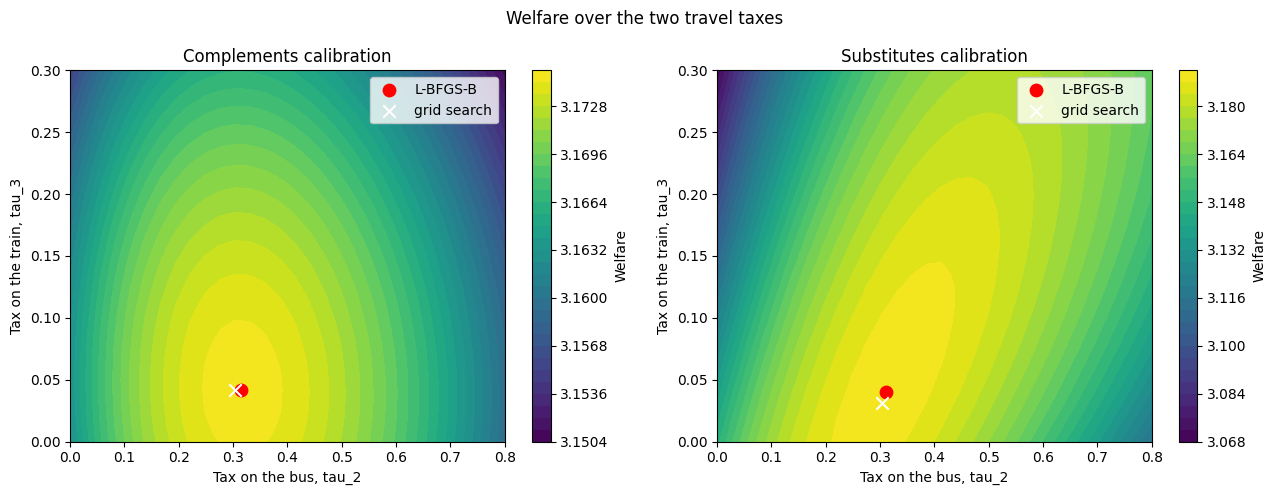

In [18]:
# check the optimizer against a grid search, and draw the welfare surface

fig,axes = plt.subplots(1,2,figsize=(13,5))

tau2_grid = np.linspace(0.0,0.8,30)
tau3_grid = np.linspace(0.0,0.3,30)

for ax,(name,green) in zip(axes,greens.items()):

    W = np.empty((tau2_grid.size,tau3_grid.size))

    for i,t2 in enumerate(tau2_grid):
        for j,t3 in enumerate(tau3_grid):
            W[i,j] = green.welfare([t2,t3])

    i,j = np.unravel_index(np.argmax(W),W.shape)
    print(f'{name}: grid search gives tau_2 = {tau2_grid[i]:.4f}, tau_3 = {tau3_grid[j]:.4f}, W = {W[i,j]:.6f}')
    print(f'{name}: L-BFGS-B   gives tau_2 = {opt_taxes[name].tau2:.4f}, tau_3 = {opt_taxes[name].tau3:.4f}, W = {opt_taxes[name].W:.6f}')

    contour = ax.contourf(tau2_grid,tau3_grid,W.T,levels=30)
    ax.scatter(opt_taxes[name].tau2,opt_taxes[name].tau3,color='red',s=80,label='L-BFGS-B')
    ax.scatter(tau2_grid[i],tau3_grid[j],color='white',marker='x',s=80,label='grid search')

    ax.set_xlabel('Tax on the bus, tau_2')
    ax.set_ylabel('Tax on the train, tau_3')
    ax.set_title(name+' calibration')
    ax.legend()

    fig.colorbar(contour,ax=ax,label='Welfare')

fig.suptitle('Welfare over the two travel taxes')
plt.tight_layout()
plt.show()

**Conclusion.**

The optimal taxes are almost the same in the two calibrations, roughly 31 percent on bus trips and 4 percent on train trips, and the ratio between them comes out at 7.5 and 7.8. That is the Pigouvian rule $\tau_j = \delta e_j/(\lambda p_j)$: the marginal utility of income $\lambda$ is common to both goods and cancels in the ratio, leaving $(e_2/p_2)/(e_3/p_3) = 7.5$. The optimizer was given no theory at all, so this is a genuine check on the numerical solution. The levels sit slightly above the naive benchmark computed at the no-tax $\lambda$, because travel gets more expensive and $\lambda$ falls a little.

What differs between the calibrations is not the tax but what it *does*. The same tax cuts emissions by 10 percent when bus and train are complements and by 25 percent when they are substitutes, and the welfare gain is almost four times larger in the substitutes case (0.044 against 0.012). The policy conclusion is that the right green tax depends only on damages and prices, while its *effect* depends entirely on how substitutable the clean and the dirty option are -- which is an argument for spending money on making the clean alternative a close substitute before, or at the same time as, taxing the dirty one.

The welfare surface also shows why this is a hard problem numerically: it is very flat around the optimum, especially in the $\tau_3$ direction, so the grid search and L-BFGS-B agree on welfare to four decimals while their tax rates still differ in the second. This is exactly the flat-surface problem we identified in question 2.1.4, and it is the reason the tolerance discussion in 2.2.4 matters.